In [4]:
from bs4 import BeautifulSoup
import requests
import numpy as np
import pandas as pd
import bs4 as bs
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

In [5]:
with open('text.txt', 'r', encoding='latin-1') as file:
    html_content = file.read()

print(f"Файл загружен, размер: {len(html_content)} символов")

# Парсим HTML
soup = BeautifulSoup(html_content, 'html.parser')

table = soup.find('table')

rows = table.find_all('tr')
print(f"   Найдено строк: {len(rows)}")

# Пропускаем первые 2 строки (заголовки)
data_rows = rows[2:] 

years = []
avg_cpi = []

for row in data_rows:
    cols = row.find_all('td')
    if len(cols) >= 15: 
        year_text = cols[0].get_text().strip()
        year_text = year_text.replace('*', '').replace('–', '').strip()
        
        if year_text.isdigit():
            year = int(year_text)
            cpi_text = cols[13].get_text().strip()
            cpi_text = cpi_text.replace('*', '').replace('–', '0').replace(',', '').strip()
            if cpi_text and cpi_text.replace('.', '').replace('-', '').isdigit():
                cpi_value = float(cpi_text)
               
                if year <= 2016:
                    years.append(year)
                    avg_cpi.append(cpi_value)

print(f"\n Собрано данных за {len(years)} лет (1913-2016)")

# Добавляем 1912 год (его нет в таблице, добавляем вручную)
cpi_1913 = avg_cpi[years.index(1913)]
cpi_1912 = round(cpi_1913 * 0.99, 1)

years.insert(0, 1912)
avg_cpi.insert(0, cpi_1912)

cpi_table = pd.DataFrame({
    "year": years,
    "avg_annual_cpi": avg_cpi
})

print(f"\n Создана таблица с {len(cpi_table)} записями (1912-2016)")

# Сохраняем в CSV
cpi_table.to_csv('Practice2_Miroshnikova_CPI.csv', index=False)
print(f"\nФайл Practice2_Miroshnikova_CPI.csv сохранен")

print("\nПервые 10 строк таблицы CPI:")
print(cpi_table.head(10).to_string(index=False))

Файл загружен, размер: 125010 символов
   Найдено строк: 116

 Собрано данных за 104 лет (1913-2016)

 Создана таблица с 105 записями (1912-2016)

Файл Practice2_Miroshnikova_CPI.csv сохранен

Первые 10 строк таблицы CPI:
 year  avg_annual_cpi
 1912             9.8
 1913             9.9
 1914            10.0
 1915            10.1
 1916            10.9
 1917            12.8
 1918            15.1
 1919            17.3
 1920            20.0
 1921            17.9


In [6]:
print("\nЗагрузка данных о фильмах...")
movies_table = pd.read_csv('../../data/Dataset1.csv', encoding='latin-1')
print(f"Загружено {len(movies_table)} фильмов")


Загрузка данных о фильмах...
Загружено 5043 фильмов


In [7]:
def get_real_value(nominal_amt, old_cpi, new_cpi):
    real_value = (nominal_amt * new_cpi) / old_cpi
    return real_value

In [8]:
CPI_2016 = float(cpi_table[cpi_table['year'] == 2016]['avg_annual_cpi'].iloc[0])
print(f"CPI для 2016 года: {CPI_2016}")

CPI для 2016 года: 240.007


In [9]:
movies_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   color                       5025 non-null   object 
 1   Director_Name               4872 non-null   object 
 2   num_Critic_for_reviews      4927 non-null   float64
 3   duration                    4959 non-null   float64
 4   director_Facebook_likes     4872 non-null   float64
 5   actor_3_Facebook_likes      4953 non-null   float64
 6   actor_2_name                4963 non-null   object 
 7   Actor_1_Facebook_likes      4968 non-null   float64
 8   gross                       4104 non-null   float64
 9   genres                      4974 non-null   object 
 10  actor_1_name                4968 non-null   object 
 11  movie_Title                 4974 non-null   object 
 12  num_voted_users             4974 non-null   float64
 13   cast_total_facebook_likes  4974 

In [10]:
movies_table.head(10)

,color,Director_Name,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_Facebook_likes,actor_2_name,Actor_1_Facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes;
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000;
1,Colour,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0;
2,Colour,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000;
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000;
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0;
5,Colour,Andrew Stanton,462.0,132.0,475.0,530.0,Samantha Morton,640.0,73058679.0,Action|Adventure|Sci-Fi,...,738.0,English,USA,PG-13,263700000.0,2012.0,632.0,6.6,2.35,24000;
6,Color,Sam Raimi,392.0,156.0,0.0,4000.0,James Franco,24000.0,336530303.0,Action|Adventure|Romance,...,1902.0,English,USA,PG-13,258000000.0,2007.0,11000.0,6.2,2.35,0;
7,Color,Nathan Greno,324.0,100.0,15.0,284.0,Donna Murphy,799.0,200807262.0,Adventure|Animation|Comedy|Family|Fantasy|Musi...,...,387.0,English,USA,PG,260000000.0,2010.0,553.0,7.8,1.85,29000;
8,Colour,Joss Whedon,635.0,141.0,0.0,19000.0,Robert Downey Jr.,26000.0,458991599.0,Action|Adventure|Sci-Fi,...,1117.0,English,USA,PG-13,250000000.0,2015.0,21000.0,7.5,2.35,118000;
9,Colour,David Yates,375.0,153.0,282.0,10000.0,Daniel Radcliffe,25000.0,301956980.0,Adventure|Family|Fantasy|Mystery,...,973.0,English,UK,PG,250000000.0,2009.0,11000.0,7.5,2.35,10000;


In [11]:
movies_table.duplicated().sum()

np.int64(45)

In [12]:
movies_table.drop_duplicates(inplace=True)
movies_table.duplicated().sum()

np.int64(0)

In [13]:
(movies_table.isna().sum()/movies_table.shape[0]*100).sort_values(ascending=False)

gross                         18.567427
budget                        10.884354
aspect_ratio                   7.723089
content_rating                 7.262905
plot_keywords                  4.281713
title_year                     3.441377
director_Facebook_likes        3.381353
Director_Name                  3.381353
num_Critic_for_reviews         2.280912
actor_3_Facebook_likes         1.780712
actor_3_name                   1.780712
num_user_for_reviews           1.720688
duration                       1.660664
facenumber_in_poster           1.620648
language                       1.620648
actor_2_facebook_likes         1.580632
actor_2_name                   1.580632
Actor_1_Facebook_likes         1.480592
actor_1_name                   1.480592
country                        1.420568
movie_imdb_link                1.360544
movie_Title                    1.360544
genres                         1.360544
 cast_total_facebook_likes     1.360544
imdb_score                     1.360544


In [14]:
movies_table.drop(["movie_imdb_link", "movie_Title", "plot_keywords"], 
                axis=1, inplace=True, errors='ignore')

movies_table.rename(columns={
    "movie_facebook_likes;": "movie_facebook_likes",
    " cast_total_facebook_likes": "cast_total_facebook_likes",
    "actor_3_Facebook_likes": "actor_3_facebook_likes",
    "Actor_1_Facebook_likes": "actor_1_facebook_likes"
}, inplace=True)

if 'movie_facebook_likes' in movies_table.columns:
    movies_table["movie_facebook_likes"] = (
        movies_table["movie_facebook_likes"]
        .astype(str)
        .str.replace(";", "")
        .pipe(pd.to_numeric, errors='coerce')
    )

numeric_columns = [
    'num_Critic_for_reviews', 'duration', 'director_Facebook_likes',
    'actor_3_facebook_likes', 'actor_1_facebook_likes', 'gross',
    'num_voted_users', 'cast_total_facebook_likes', 'facenumber_in_poster',
    'num_user_for_reviews', 'budget', 'title_year', 'actor_2_facebook_likes',
    'imdb_score', 'aspect_ratio', 'movie_facebook_likes'
]

for col in numeric_columns:
    if col in movies_table.columns:
        movies_table[col] = pd.to_numeric(movies_table[col], errors='coerce')

categorical_columns = [
    'color', 'Director_Name', 'actor_2_name', 'genres', 
    'actor_1_name', 'actor_3_name', 'language', 'country', 'content_rating'
]

for col in categorical_columns:
    if col in movies_table.columns and movies_table[col].isna().any():
        mode_val = movies_table[col].mode()
        movies_table[col] = movies_table[col].fillna(mode_val[0] if len(mode_val) > 0 else "Unknown")

for col in movies_table.select_dtypes(include=['int64', 'float64']).columns:
    if movies_table[col].isna().any():
        median_val = movies_table[col].median()
        if pd.isna(median_val):
            movies_table[col] = movies_table[col].fillna(0)
        else:
            movies_table[col] = movies_table[col].fillna(median_val)

In [15]:
(movies_table.isna().sum()/movies_table.shape[0]*100).sort_values(ascending=False)

color                        0.0
Director_Name                0.0
num_Critic_for_reviews       0.0
duration                     0.0
director_Facebook_likes      0.0
actor_3_facebook_likes       0.0
actor_2_name                 0.0
actor_1_facebook_likes       0.0
gross                        0.0
genres                       0.0
actor_1_name                 0.0
num_voted_users              0.0
cast_total_facebook_likes    0.0
actor_3_name                 0.0
facenumber_in_poster         0.0
num_user_for_reviews         0.0
language                     0.0
country                      0.0
content_rating               0.0
budget                       0.0
title_year                   0.0
actor_2_facebook_likes       0.0
imdb_score                   0.0
aspect_ratio                 0.0
movie_facebook_likes         0.0
dtype: float64

In [16]:
print("\n Преобразование бюджетов и сборов в доллары 2016 года")
real_domestic_gross = []
real_budget_values = []

for index, row in movies_table.iterrows():
    gross = row['gross']
    budget = row['budget']
    year = row['title_year']
    cpi = float(cpi_table[cpi_table['year'] == int(year)]['avg_annual_cpi'].iloc[0])

    real_gross = get_real_value(gross, cpi, CPI_2016)
    real_budget = get_real_value(budget, cpi, CPI_2016)
    real_domestic_gross.append(real_gross)
    real_budget_values.append(real_budget)

movies_table["real_domestic_gross"] = real_domestic_gross
movies_table["real_budget"] = real_budget_values


 Преобразование бюджетов и сборов в доллары 2016 года


In [17]:
print("\n Расчет прибыли и ROI")

profits = []
roi_vals = []

for index, row in movies_table.iterrows():
    if not pd.isna(row['real_domestic_gross']) and not pd.isna(row['real_budget']) and row['real_budget'] > 0:
        profit = row['real_domestic_gross'] - row['real_budget']
        roi = (profit / row['real_budget']) * 100  
    else:
        profit = np.nan
        roi = np.nan
    
    profits.append(profit)
    roi_vals.append(roi)

movies_table['profit'] = profits
movies_table['roi'] = roi_vals


 Расчет прибыли и ROI


In [18]:
movies_table.head(10)

,color,Director_Name,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,real_domestic_gross,real_budget,profit,roi
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,237000000.0,2009.0,936.0,7.9,1.78,33000.0,8.507937e+08,2.651368e+08,5.856569e+08,220.888543
1,Colour,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,300000000.0,2007.0,5000.0,7.1,2.35,0.0,3.582208e+08,3.473329e+08,1.088790e+07,3.134717
2,Colour,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,245000000.0,2015.0,393.0,6.8,2.35,85000.0,2.025981e+08,2.480907e+08,-4.549257e+07,-18.337071
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,250000000.0,2012.0,23000.0,8.5,2.35,164000.0,4.684551e+08,2.613385e+08,2.071167e+08,79.252257
4,Color,Doug Walker,110.0,103.0,131.0,372.0,Rob Walker,131.0,25529689.5,Documentary,...,20000000.0,2005.0,12.0,7.1,2.35,0.0,3.137381e+07,2.457829e+07,6.795516e+06,27.648447
5,Colour,Andrew Stanton,462.0,132.0,475.0,530.0,Samantha Morton,640.0,73058679.0,Action|Adventure|Sci-Fi,...,263700000.0,2012.0,632.0,6.6,2.35,24000.0,7.637218e+07,2.756598e+08,-1.992877e+08,-72.294775
6,Color,Sam Raimi,392.0,156.0,0.0,4000.0,James Franco,24000.0,336530303.0,Action|Adventure|Romance,...,258000000.0,2007.0,11000.0,6.2,2.35,0.0,3.896268e+08,2.987063e+08,9.092051e+07,30.438102
7,Color,Nathan Greno,324.0,100.0,15.0,284.0,Donna Murphy,799.0,200807262.0,Adventure|Animation|Comedy|Family|Fantasy|Musi...,...,260000000.0,2010.0,553.0,7.8,1.85,29000.0,2.210219e+08,2.861734e+08,-6.515148e+07,-22.766438
8,Colour,Joss Whedon,635.0,141.0,0.0,19000.0,Robert Downey Jr.,26000.0,458991599.0,Action|Adventure|Sci-Fi,...,250000000.0,2015.0,21000.0,7.5,2.35,118000.0,4.647818e+08,2.531538e+08,2.116281e+08,83.596640
9,Colour,David Yates,375.0,153.0,282.0,10000.0,Daniel Radcliffe,25000.0,301956980.0,Adventure|Family|Fantasy|Mystery,...,250000000.0,2009.0,11000.0,7.5,2.35,10000.0,3.378055e+08,2.796802e+08,5.812535e+07,20.782792


In [19]:
movies_table.describe()

,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,gross,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,real_domestic_gross,real_budget,profit,roi
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4.998000e+03,4.998000e+03,4998.000000,4998.000000,4998.000000,4.998000e+03,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4.998000e+03,4.998000e+03,4.998000e+03,4.998000e+03
mean,139.569828,107.134054,671.668467,637.690076,6486.546819,4.421258e+07,8.294089e+04,9615.156663,1.364346,270.765106,3.780870e+07,2002.574230,1634.262305,6.440696,2.234130,7431.832733,6.793342e+07,4.894159e+07,1.899183e+07,1.627825e+03
std,120.413150,24.823597,2784.381897,1636.346970,15020.428505,6.203925e+07,1.374407e+05,18120.824350,2.002276,375.564051,1.966829e+08,12.225484,4014.190994,1.115392,1.344574,19278.521606,1.232866e+08,2.391459e+08,2.620484e+08,3.121086e+04
min,1.000000,7.000000,0.000000,0.000000,0.000000,1.620000e+02,5.000000e+00,0.000000,0.000000,1.000000,2.180000e+02,1916.000000,0.000000,1.600000,1.180000,0.000000,1.642384e+02,2.843561e+02,-1.454007e+10,-9.999820e+01
25%,51.000000,93.000000,8.000000,138.250000,624.000000,9.019928e+06,8.915750e+03,1440.000000,0.000000,67.000000,7.500000e+06,1999.000000,288.250000,5.800000,1.850000,0.000000,1.192644e+07,1.115061e+07,-1.116675e+07,-4.903385e+01
50%,110.000000,103.000000,49.000000,372.000000,989.000000,2.552969e+07,3.444200e+04,3089.500000,1.000000,156.000000,2.000000e+07,2005.000000,595.000000,6.600000,2.350000,162.500000,3.137381e+07,2.457829e+07,6.086346e+06,2.764845e+01
75%,192.000000,117.000000,188.000000,631.000000,11000.000000,5.090628e+07,9.437825e+04,13624.250000,2.000000,322.000000,4.000000e+07,2010.000000,912.000000,7.200000,2.350000,3000.000000,7.785450e+07,5.471662e+07,2.979812e+07,1.671432e+02
max,813.000000,511.000000,23000.000000,23000.000000,640000.000000,7.605058e+08,1.689764e+06,656730.000000,43.000000,5060.000000,1.221550e+10,2016.000000,137000.000000,9.500000,16.000000,349000.000000,3.430119e+09,1.454269e+10,3.361450e+09,1.823449e+06


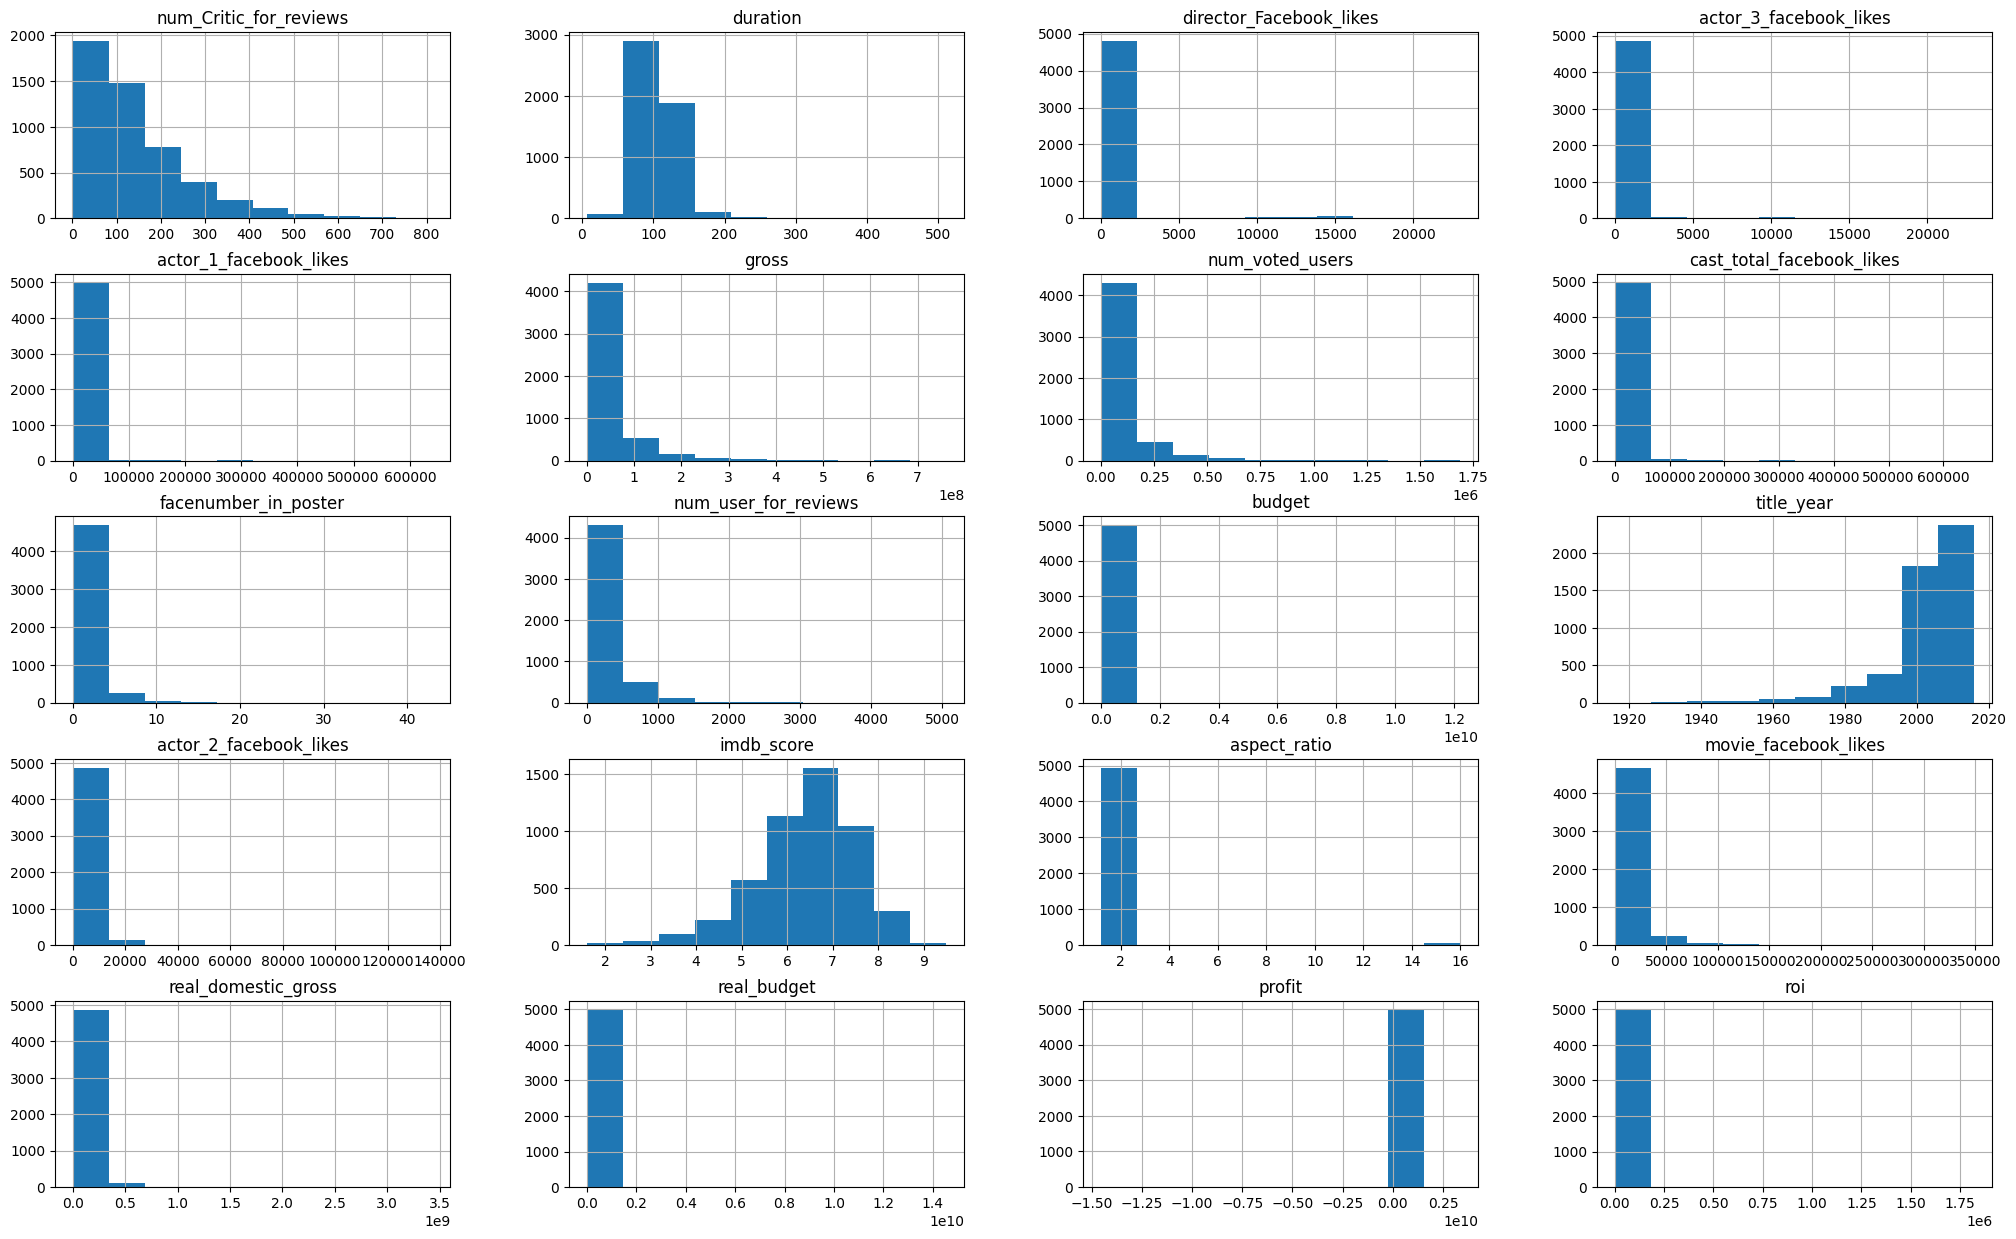

In [20]:
movies_table.hist(figsize=(25, 15))
plt.show()

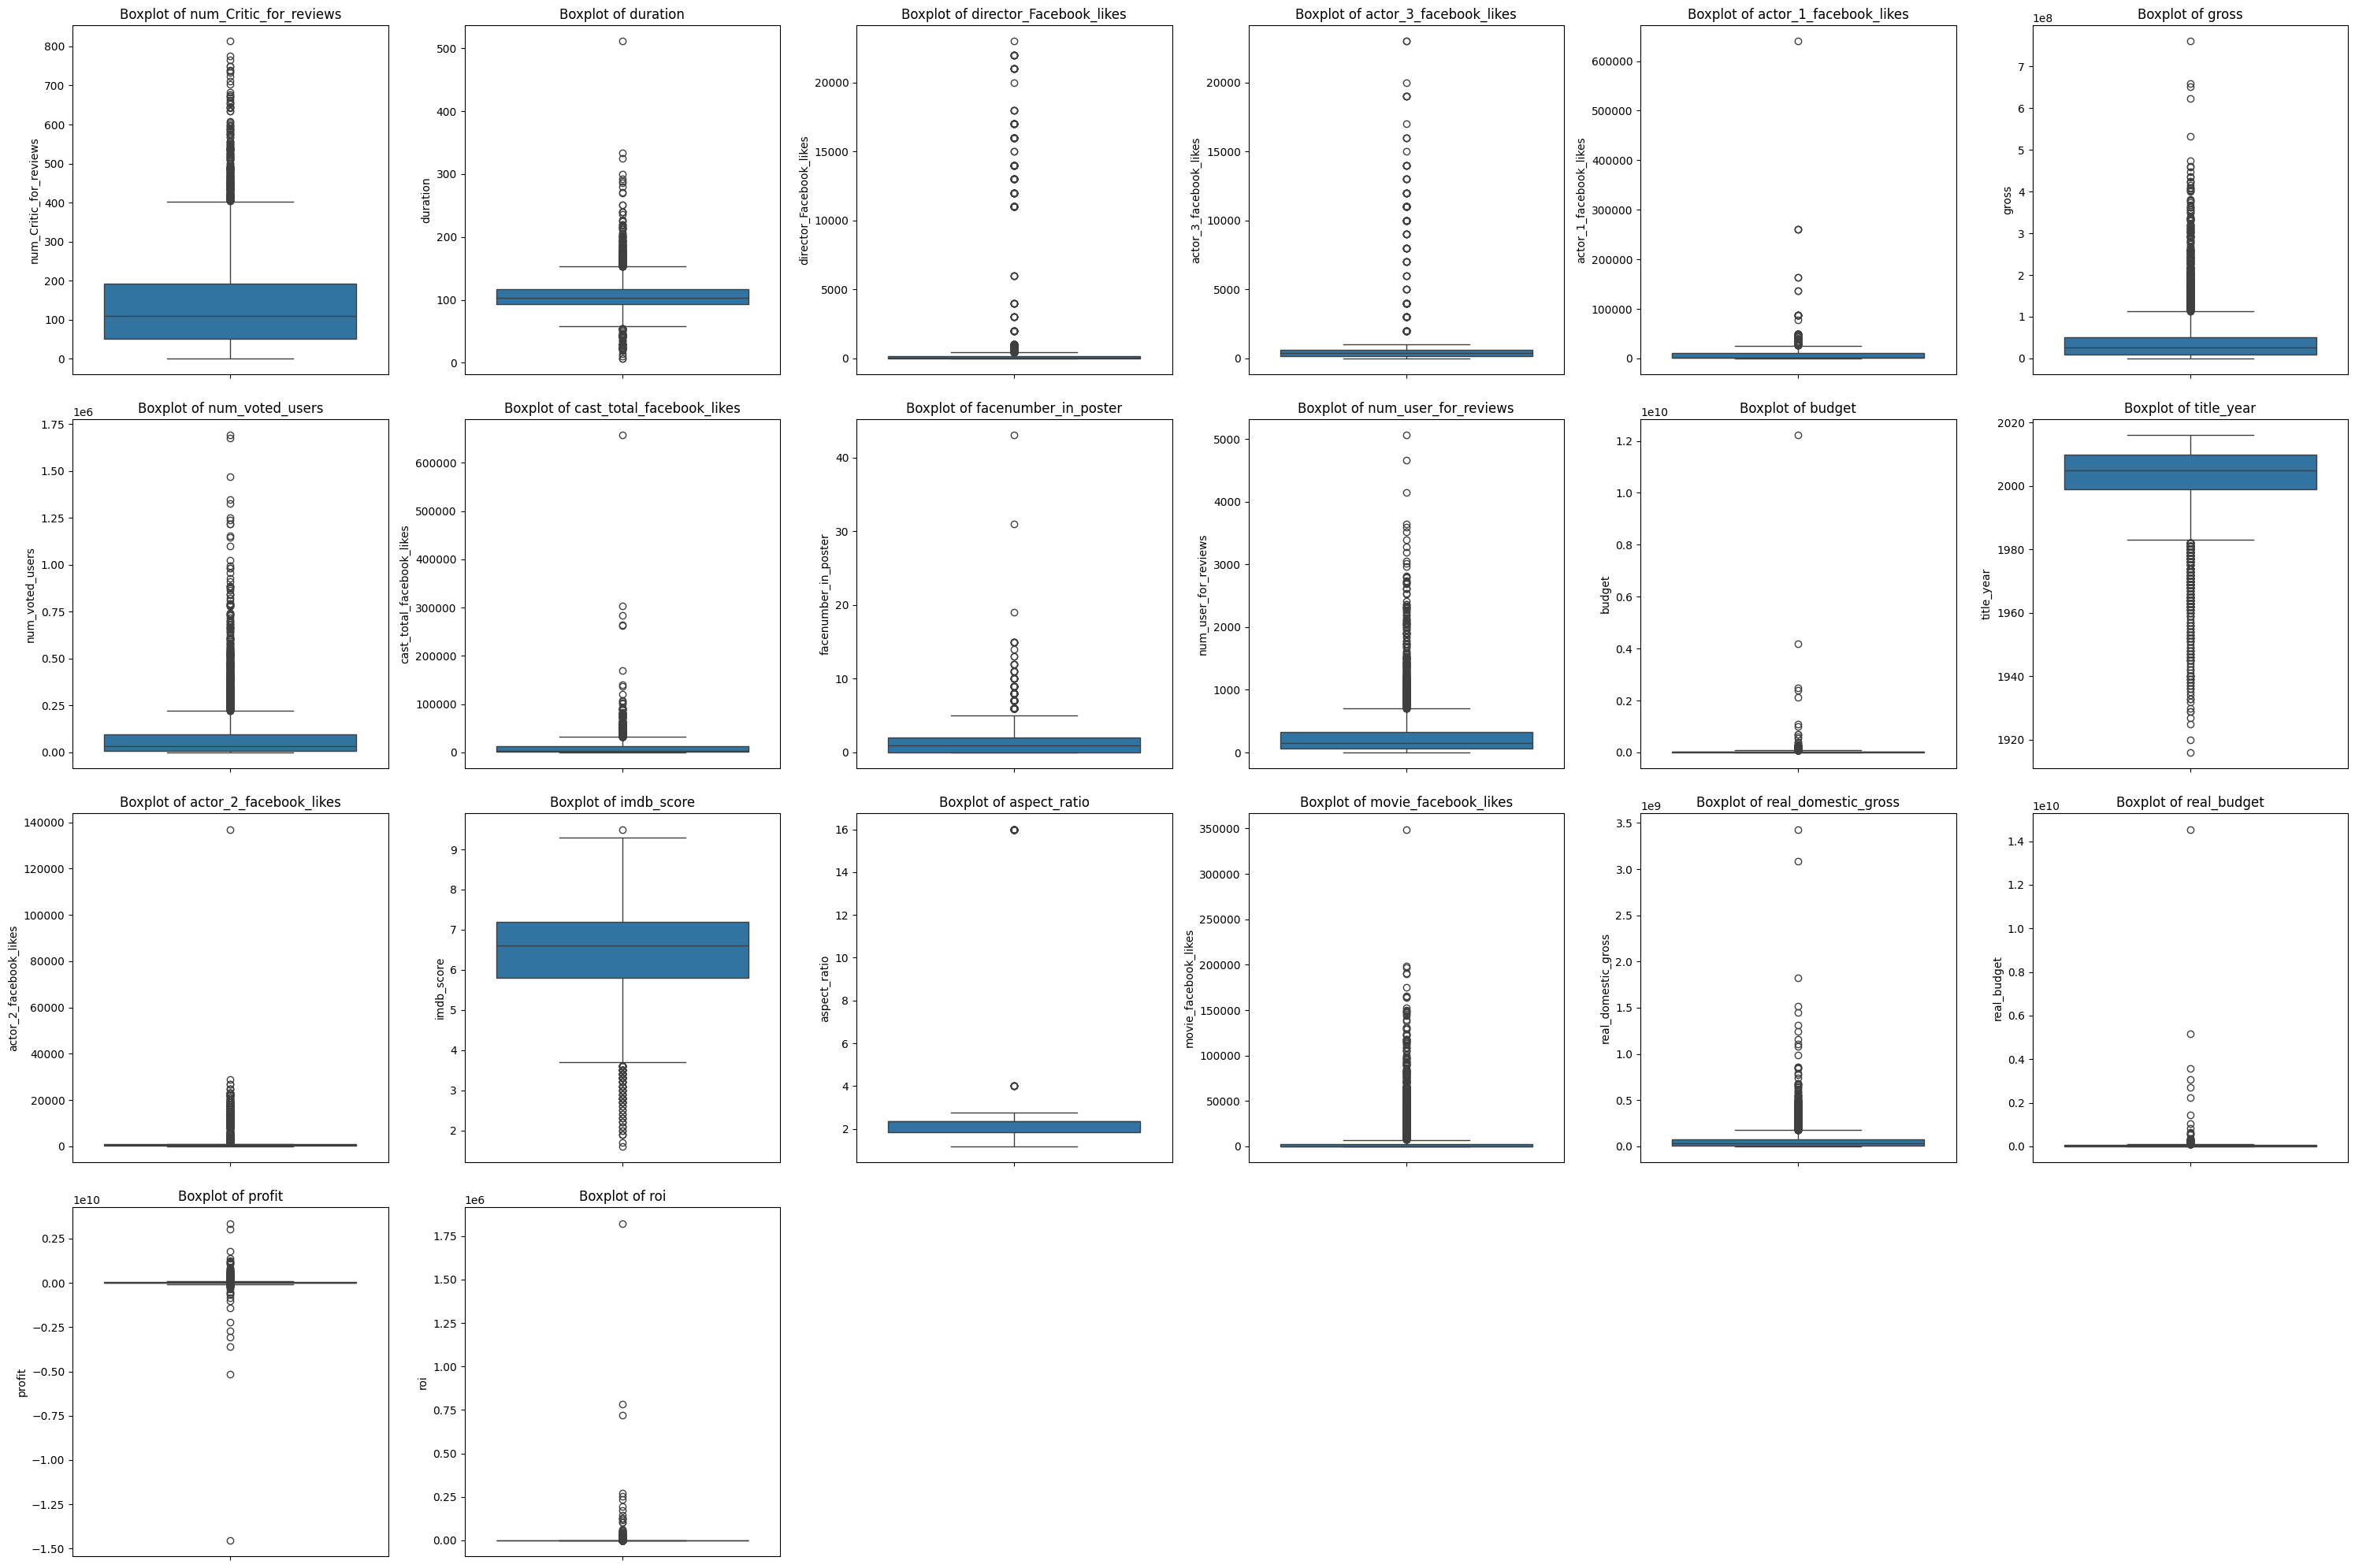

In [21]:
numeric_columns = movies_table.select_dtypes(include=["float64", "int64"]).columns
n_cols = len(numeric_columns)

n_rows = (n_cols + 5) // 6 

fig, axs = plt.subplots(n_rows, 6, figsize=(30, 5*n_rows))
plt.subplots_adjust(wspace=0.4, hspace=0.3)

ax_flatten = axs.flatten()

for i, col in enumerate(numeric_columns):
    sns.boxplot(data=movies_table, y=col, ax=ax_flatten[i])
    ax_flatten[i].set_title(f'Boxplot of {col}')
    ax_flatten[i].set_ylabel(col)

for j in range(len(numeric_columns), len(ax_flatten)):
    ax_flatten[j].set_visible(False)

plt.tight_layout()
plt.show()

# Анализ выбросов в данных о фильмах

Практически во всех представленных переменных наблюдаются **многочисленные выбросы**. Это характерно для данных, связанных с кинопроизводством (бюджеты, сборы, лайки в соцсетях), где несколько блокбастеров или популярных актеров сильно выделяются на фоне основной массы фильмов.

---

## Детальный анализ по группам

### 1. Переменные с явными и многочисленными выбросами
В этих категориях основная масса данных сконцентрирована у минимальных значений, но присутствует "длинный хвост" из очень высоких значений (выбросов).

*   **`num_Critic_for_reviews` (Количество критиков):** Есть фильмы, которые получили аномально большое количество рецензий по сравнению с основной массой.
*   **`duration` (Длительность):** Существуют фильмы, значительно превышающие стандартный хронометраж (вероятно, эпические картины или экспериментальное кино).
*   **Facebook лайки (`director_Facebook_likes`, `actor_1/2/3_facebook_likes`, `cast_total_facbook_likes`):**
    *   У нескольких режиссеров и актеров необычайно высокая популярность в Facebook по сравнению с коллегами.
    *   Суммарные лайки актерского состава (`cast_total_facbook_likes`) также имеют выбросы — это фильмы с исключительно популярным кастом.
*   **`num_voted_users` (Количество проголосовавших пользователей):** Есть фильмы-блокбастеры, собравшие голоса миллионов, что является выбросом на фоне тысяч менее популярных фильмов.
*   **`num_user_for_reviews` (Количество пользовательских рецензий):** Аналогично предыдущему пункту, некоторые фильмы вызывают аномально высокий интерес у аудитории к написанию рецензий.
*   **`budget` (Бюджет):** Классический случай. Несколько высокобюджетных голливудских постановок будут являться сильными выбросами на фоне независимого или малобюджетного кино. Однако, значения меньше 1000 не могут соответствовать реальности, поскольку производство даже самого малобюджетного фильма требует затрат (оборудование, съёмочная группа, постпродакшн). Минимальный бюджет для независимого кино начинается от нескольких тысяч долларов. Такие данные стоит удалить.
*   **`gross` (Сборы) и `real_domestic_gross`:** Блокбастеры с кассой в миллиард долларов резко выделяются на фоне фильмов, окупившихся едва-едва.
*   **`profit` (Прибыль) и `ROI` (Рентабельность):** Некоторые фильмы могут стать "мега-хитами" с колоссальной прибылью, что будет выбросом. (Примечание: ROI может также иметь выбросы в отрицательную сторону для фильмов-катастроф, прогоревших в прокате).

### 2. Переменные с потенциальными выбросами
*   **`imdb_score` (Рейтинг IMDB):**
    *   Вероятно, будут присутствовать выбросы как снизу (очень плохие фильмы с рейтингом 1-2), так и сверху (шедевры с рейтингом 8.5+).
*   **`aspect_ratio` (Соотношение сторон):**
    *   Данные в таблице показывают выбросы, помеченные как `(inset)`. Большинство фильмов снимается в стандартных соотношениях (1.85, 2.35). Любое отклонение от них (например, 1.33 или экспериментальные форматы) будет считаться выбросом. Такие данные тоже стоит удалить.
*   **`facebook_in_poster` (Наличие логотипа Facebook на постере):**
    *   Так как это, скорее всего, бинарная или слабо варьирующаяся величина, выбросы здесь маловероятны или будут связаны с ошибками ввода данных.

### 3. Переменная без выбросов
*   **`title_year` (Год выпуска):**
    *   Распределение годов в наборе данных, скорее всего, равномерное или близкое к нормальному в пределах выборки. Выбросов быть не должно, если только в данные не попала случайно дата из будущего или далекого прошлого, выбивающаяся из общей хронологии (например, фильм 1890 года в выборке за 2000-е).

--- 


In [22]:
movies_table_clean = movies_table.copy()
# Удаляем строки с бюджетом 0 или < 1000
if 'budget' in movies_table_clean.columns:
    before = len(movies_table_clean)
    movies_table_clean = movies_table_clean[~((movies_table_clean['budget'] == 0) | (movies_table_clean['budget'] < 1000))]
    print(f"Удалено {before - len(movies_table_clean)} строк с budget=0 или budget<1000")

# Удаляем строки с aspect_ratio < 0.5 или > 5
if 'aspect_ratio' in movies_table_clean.columns:
    before = len(movies_table_clean)
    movies_table_clean = movies_table_clean[(movies_table_clean['aspect_ratio'] >= 0.5) & (movies_table_clean['aspect_ratio'] <= 5)]
    print(f"Удалено {before - len(movies_table_clean)} строк с aspect_ratio<0.5 или aspect_ratio>5")


Удалено 1 строк с budget=0 или budget<1000
Удалено 45 строк с aspect_ratio<0.5 или aspect_ratio>5


### 1. Как распределены рейтинги фильмов (IMDb score)?

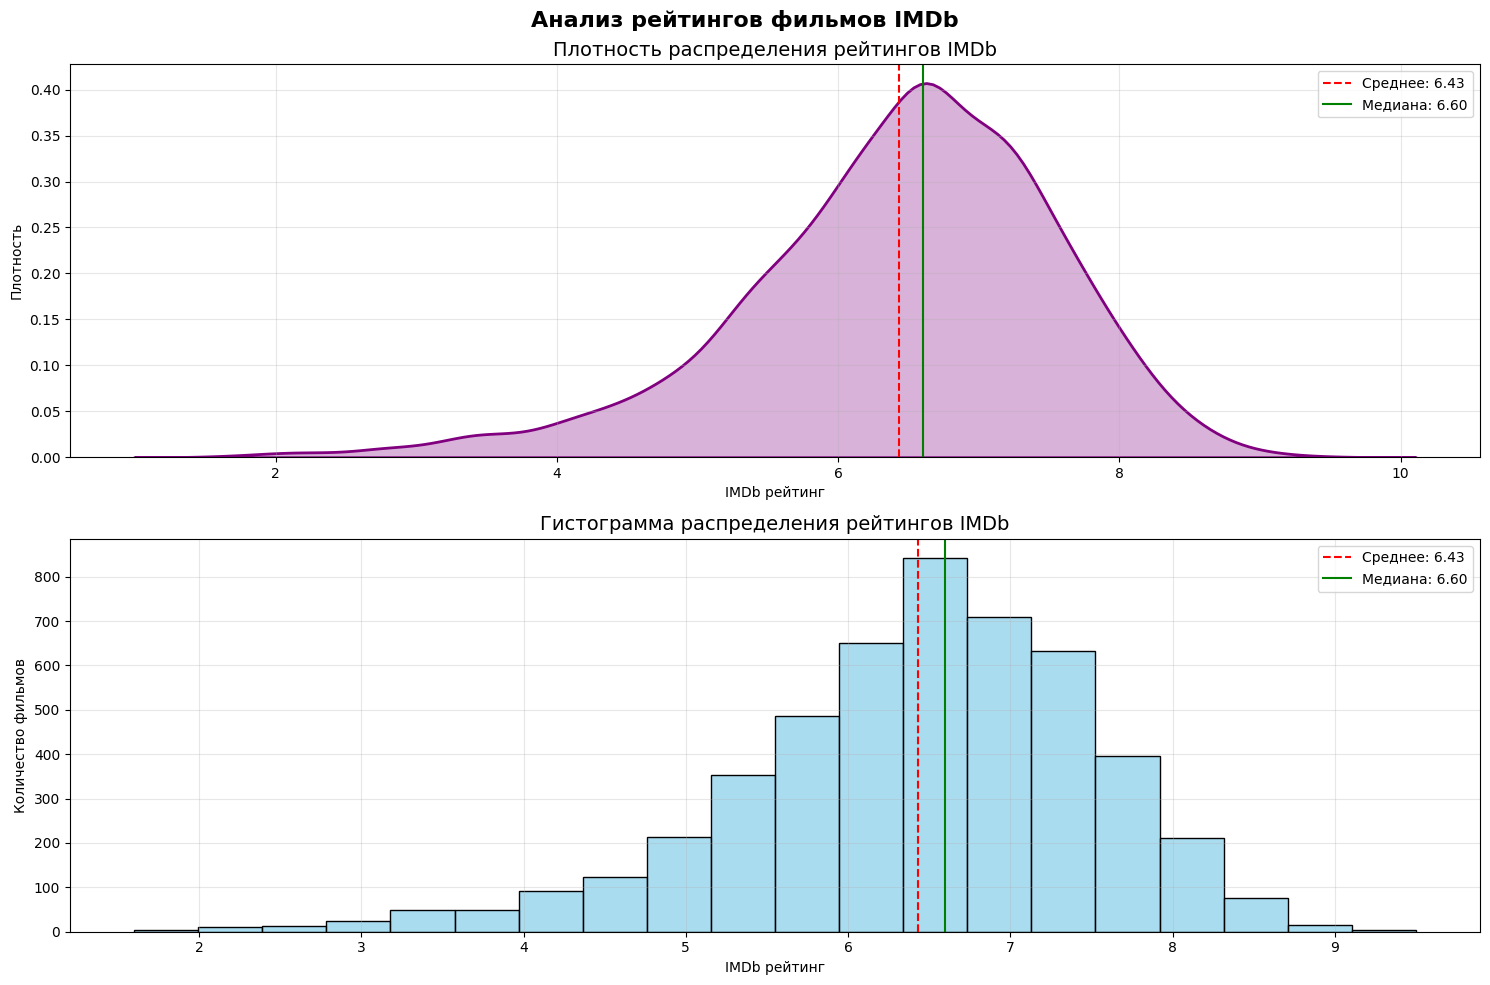

In [23]:
fig, ax = plt.subplots(2, 1, figsize=(15, 10))

sns.kdeplot(movies_table_clean["imdb_score"], ax=ax[0], color='purple', linewidth=2, fill=True, alpha=0.3)
ax[0].axvline(movies_table_clean["imdb_score"].mean(), color='red', linestyle='--', label=f'Среднее: {movies_table_clean["imdb_score"].mean():.2f}')
ax[0].axvline(movies_table_clean["imdb_score"].median(), color='green', linestyle='-', label=f'Медиана: {movies_table_clean["imdb_score"].median():.2f}')
ax[0].set_title('Плотность распределения рейтингов IMDb', fontsize=14)
ax[0].set_xlabel('IMDb рейтинг')
ax[0].set_ylabel('Плотность')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

sns.histplot(movies_table_clean["imdb_score"], ax=ax[1], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax[1].axvline(movies_table_clean["imdb_score"].mean(), color='red', linestyle='--', label=f'Среднее: {movies_table_clean["imdb_score"].mean():.2f}')
ax[1].axvline(movies_table_clean["imdb_score"].median(), color='green', linestyle='-', label=f'Медиана: {movies_table_clean["imdb_score"].median():.2f}')
ax[1].set_title('Гистограмма распределения рейтингов IMDb', fontsize=14)
ax[1].set_xlabel('IMDb рейтинг')
ax[1].set_ylabel('Количество фильмов')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

fig.suptitle('Анализ рейтингов фильмов IMDb', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

Распределение рейтингов фильмов близко к нормальному распределению.

### 2. Существует ли зависимость между бюджетом фильма и его кассовыми сборами?

Text(0.5, 1.0, 'Корреляционная матрица')

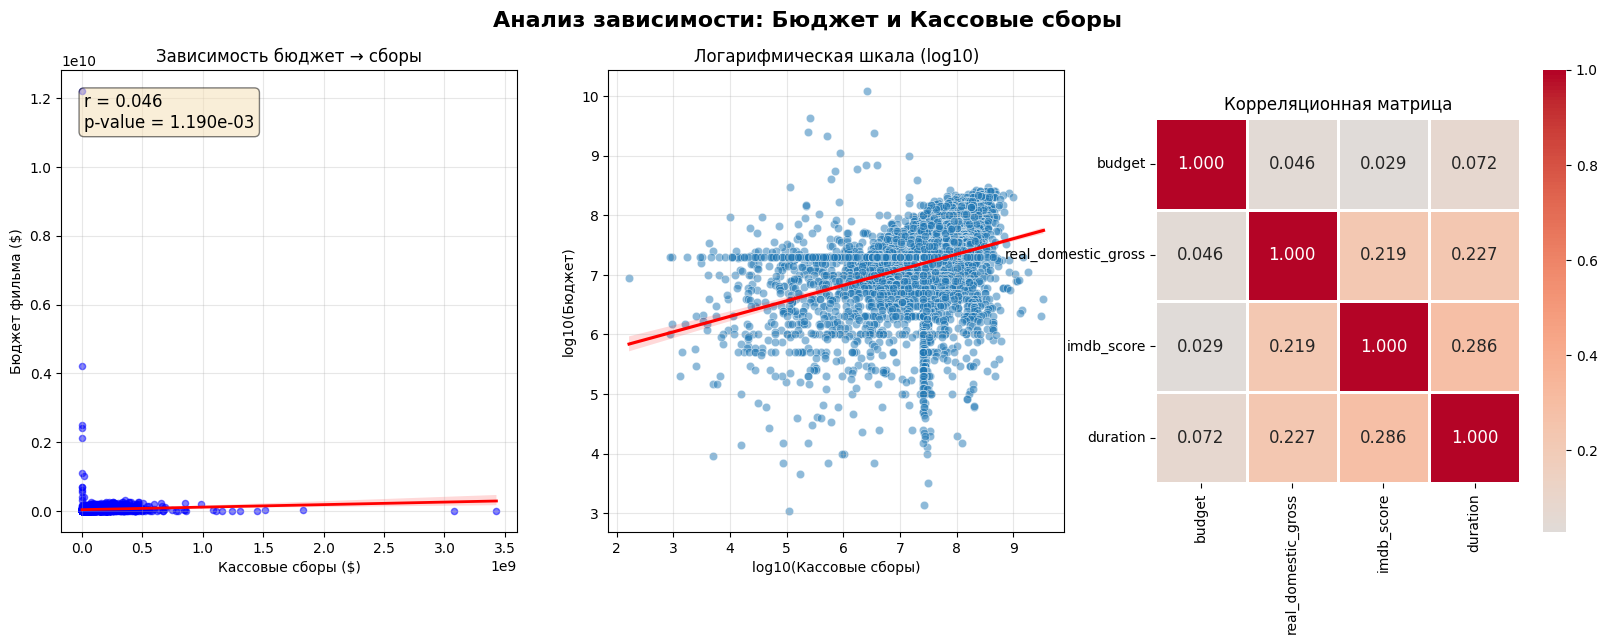

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Анализ зависимости: Бюджет и Кассовые сборы ', fontsize=16, fontweight='bold')

ax1 = axes[0]
sns.regplot(data=movies_table_clean, x="real_domestic_gross", y="budget", 
            scatter_kws={'alpha':0.5, 's':20, 'color':'blue'},
            line_kws={'color':'red', 'linewidth':2},
            ci=95, ax=ax1)
ax1.set_title('Зависимость бюджет → сборы', fontsize=12)
ax1.set_xlabel('Кассовые сборы ($)')
ax1.set_ylabel('Бюджет фильма ($)')
ax1.grid(True, alpha=0.3)

corr, p_value = stats.pearsonr(movies_table_clean['budget'].dropna(), 
                                movies_table_clean['real_domestic_gross'].dropna())
ax1.text(0.05, 0.95, f'r = {corr:.3f}\np-value = {p_value:.3e}', 
         transform=ax1.transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


ax2 = axes[1]
df_log = movies_table_clean[(movies_table_clean['budget'] > 0) & 
                            (movies_table_clean['real_domestic_gross'] > 0)].copy()
df_log['log_budget'] = np.log10(df_log['budget'])
df_log['log_gross'] = np.log10(df_log['real_domestic_gross'])

sns.scatterplot(data=df_log, x='log_gross', y='log_budget', alpha=0.5, ax=ax2)
sns.regplot(data=df_log, x='log_gross', y='log_budget', 
            scatter=False, color='red', ax=ax2)

ax2.set_title('Логарифмическая шкала (log10)', fontsize=12)
ax2.set_xlabel('log10(Кассовые сборы)')
ax2.set_ylabel('log10(Бюджет)')
ax2.grid(True, alpha=0.3)

ax3 = axes[2]
corr_data = movies_table_clean[['budget', 'real_domestic_gross', 'imdb_score', 'duration']].corr()
sns.heatmap(corr_data, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, ax=ax3, 
            annot_kws={'size': 12}, fmt='.3f')
ax3.set_title('Корреляционная матрица', fontsize=12)

Между бюджетом фильма и его кассовыми сборами зависимости нет.

### 3. Какие жанры встречаются чаще всего?

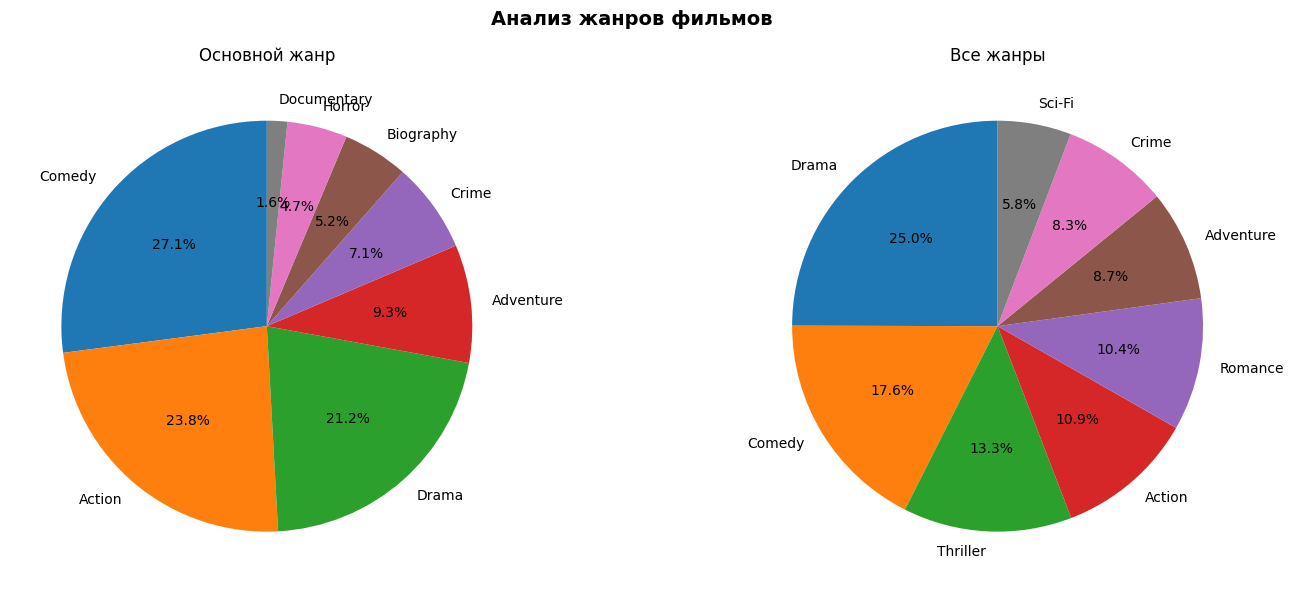

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Анализ жанров фильмов', fontsize=14, fontweight='bold')

main_genres = movies_table_clean["genres"].str.split('|').str[0]
main_genres_count = main_genres.value_counts().head(8)

ax[0].pie(main_genres_count.values, 
          labels=main_genres_count.index, 
          autopct='%1.1f%%',
          startangle=90)
ax[0].set_title("Основной жанр", fontsize=12)

all_genres = movies_table_clean["genres"].str.split('|').explode()
all_genres_count = all_genres.value_counts().head(8)

ax[1].pie(all_genres_count.values, 
          labels=all_genres_count.index, 
          autopct='%1.1f%%',
          startangle=90)
ax[1].set_title("Все жанры", fontsize=12)

plt.tight_layout()
plt.show()

Жанры: комедия, экшен и драма - наиболее популярные жанры.


### 4. Влияет ли количество проголосовавших пользователей на итоговый рейтинг?

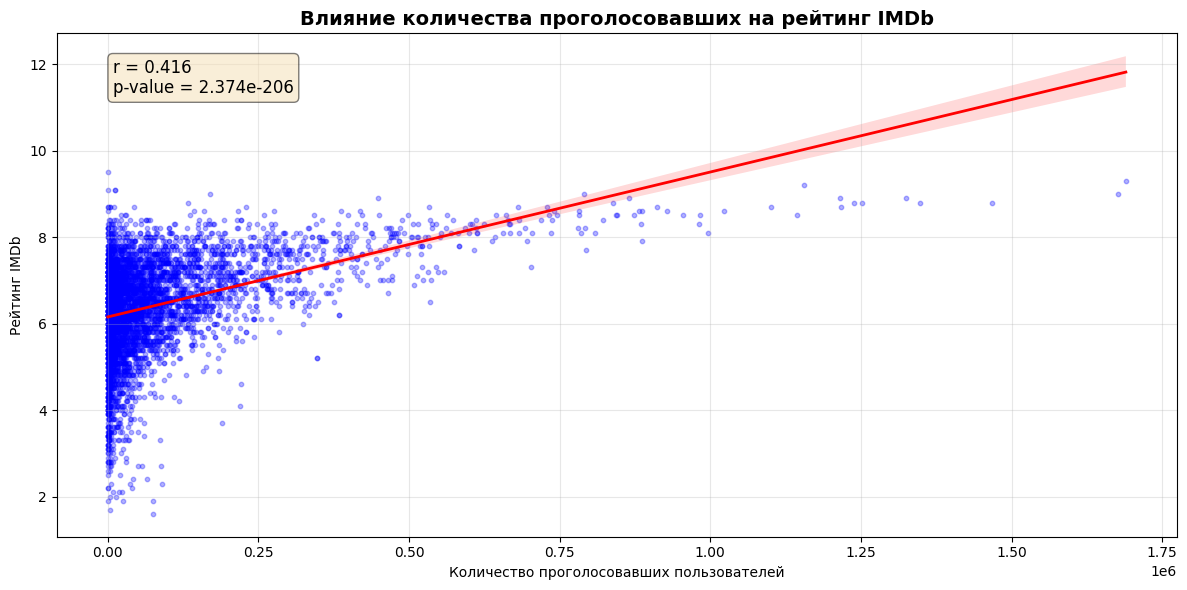

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.regplot(data=movies_table_clean, x="num_voted_users", y="imdb_score",
            scatter_kws={'alpha':0.3, 's':10, 'color':'blue'},
            line_kws={'color':'red', 'linewidth':2},
            ax=ax)
ax.set_title('Влияние количества проголосовавших на рейтинг IMDb', fontsize=14, fontweight='bold')
ax.set_xlabel('Количество проголосовавших пользователей')
ax.set_ylabel('Рейтинг IMDb')
ax.grid(True, alpha=0.3)

corr, p_value = stats.pearsonr(movies_table_clean['num_voted_users'].dropna(), 
                                movies_table_clean['imdb_score'].dropna())
ax.text(0.05, 0.95, f'r = {corr:.3f}\np-value = {p_value:.3e}', 
         transform=ax.transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

Связь между количеством голосов и рейтингом существует, но она не прямая. У популярных фильмов оценки обычно выше среднего, но крайних значений (выше 9 или ниже 5) среди них мало. Настоящие шедевры с рейтингом 9+ чаще встречаются среди фильмов с умеренной популярностью — это культовая классика.

### 5. Есть ли связь между суммарными лайками актёров в Facebook и рейтингом фильма?

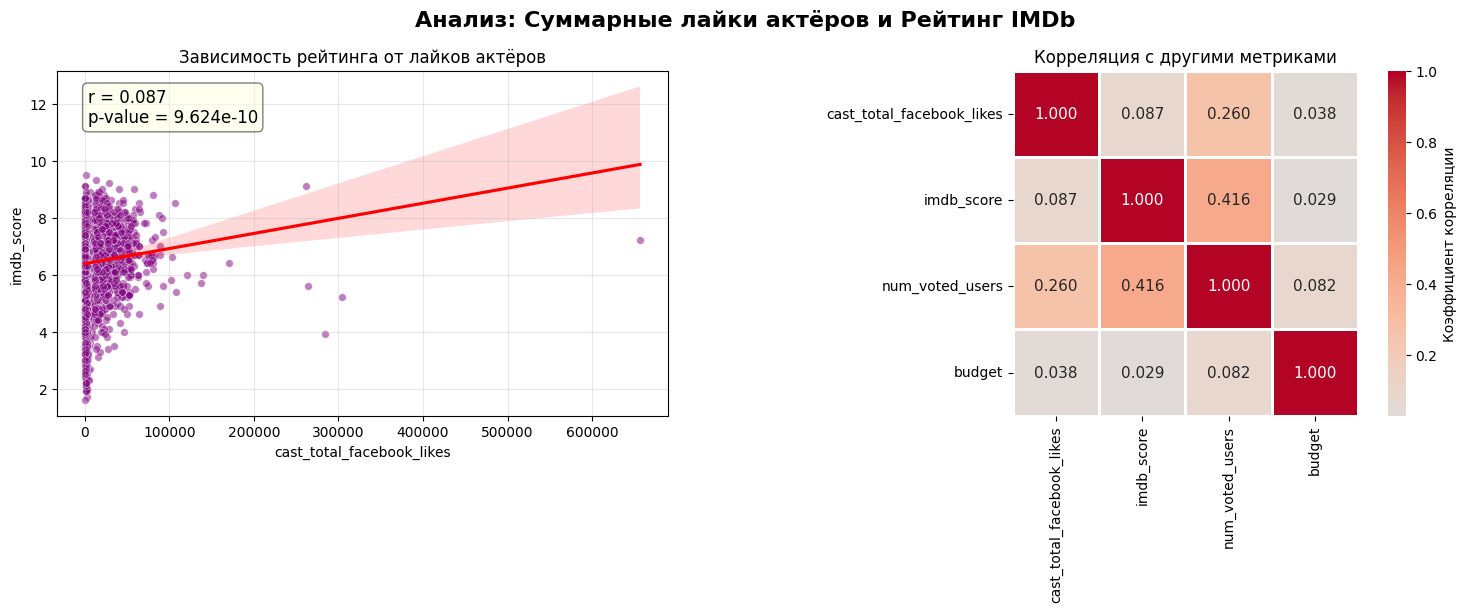

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Анализ: Суммарные лайки актёров и Рейтинг IMDb', fontsize=16, fontweight='bold')

ax1 = axes[0]
sns.scatterplot(data=movies_table_clean, 
                x="cast_total_facebook_likes", 
                y="imdb_score",
                alpha=0.5,
                s=30,
                color='purple',
                ax=ax1)
ax1.set_title('Зависимость рейтинга от лайков актёров', fontsize=12)
ax1.set_xlabel('Суммарные лайки актёров в Facebook')
ax1.set_ylabel('Рейтинг IMDb')
ax1.grid(True, alpha=0.3)

sns.regplot(data=movies_table_clean, 
            x="cast_total_facebook_likes", 
            y="imdb_score",
            scatter=False,
            color='red',
            ax=ax1)

corr, p_value = stats.pearsonr(movies_table_clean['cast_total_facebook_likes'].dropna(), 
                                movies_table_clean['imdb_score'].dropna())
ax1.text(0.05, 0.95, f'r = {corr:.3f}\np-value = {p_value:.3e}', 
         transform=ax1.transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

ax2 = axes[1]

corr_data = movies_table_clean[['cast_total_facebook_likes', 
                                 'imdb_score', 
                                 'num_voted_users', 
                                 'budget']].corr()

sns.heatmap(corr_data, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True, 
            linewidths=1,
            ax=ax2,
            annot_kws={'size': 11},
            fmt='.3f',
            cbar_kws={'label': 'Коэффициент корреляции'})

ax2.set_title('Корреляция с другими метриками', fontsize=12)

plt.tight_layout()
plt.show()

Звёздный состав скорее создаёт благоприятные условия для высоких оценок, но не гарантирует их. Качество фильма определяется не только именами актёров.

### 6. Как изменялся средний бюджет фильмов по годам?

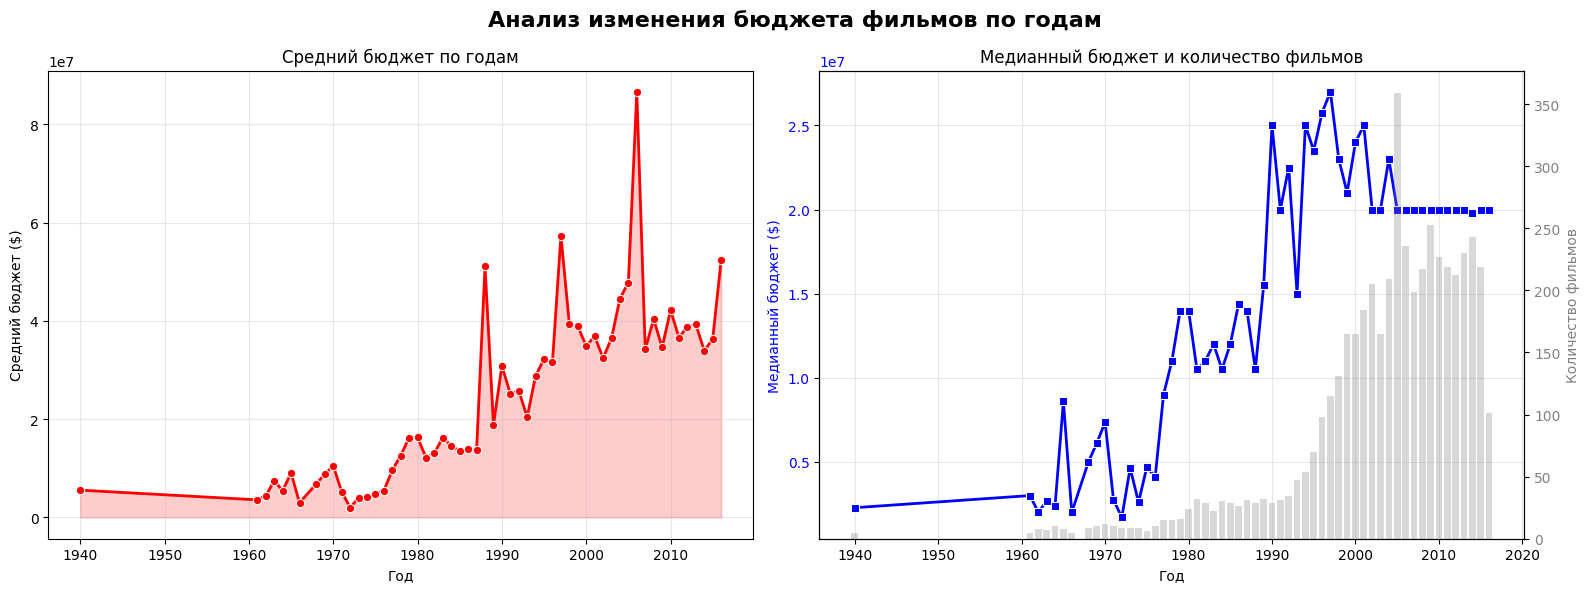

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Анализ изменения бюджета фильмов по годам', fontsize=16, fontweight='bold')

yearly = movies_table_clean.groupby('title_year')['budget'].agg(['mean', 'median', 'count']).reset_index()
yearly = yearly[yearly['count'] >= 5]  

sns.lineplot(data=yearly, x='title_year', y='mean', marker='o', color='red', linewidth=2, ax=axes[0])
axes[0].fill_between(yearly['title_year'], yearly['mean'], alpha=0.2, color='red')
axes[0].set_title('Средний бюджет по годам', fontsize=12)
axes[0].set_xlabel('Год')
axes[0].set_ylabel('Средний бюджет ($)')
axes[0].grid(True, alpha=0.3)

sns.lineplot(data=yearly, x='title_year', y='median', marker='s', color='blue', linewidth=2, ax=axes[1])
axes[1].set_title('Медианный бюджет и количество фильмов', fontsize=12)
axes[1].set_xlabel('Год')
axes[1].set_ylabel('Медианный бюджет ($)', color='blue')
axes[1].tick_params(axis='y', labelcolor='blue')
axes[1].grid(True, alpha=0.3)

ax2 = axes[1].twinx()
ax2.bar(yearly['title_year'], yearly['count'], alpha=0.3, color='gray', width=0.8)
ax2.set_ylabel('Количество фильмов', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

plt.tight_layout()
plt.show()

Средний бюджет фильмов рос с 1940-х по 2000-е годы, достигнув пика в 6.5 млн, после чего к 2010-м снизился до 4 млн. При этом медианный бюджет (типичный фильм) всегда был значительно ниже среднего, что указывает на влияние дорогих блокбастеров на общую статистику.

###  7. Какие страны лидируют по количеству произведённых фильмов?

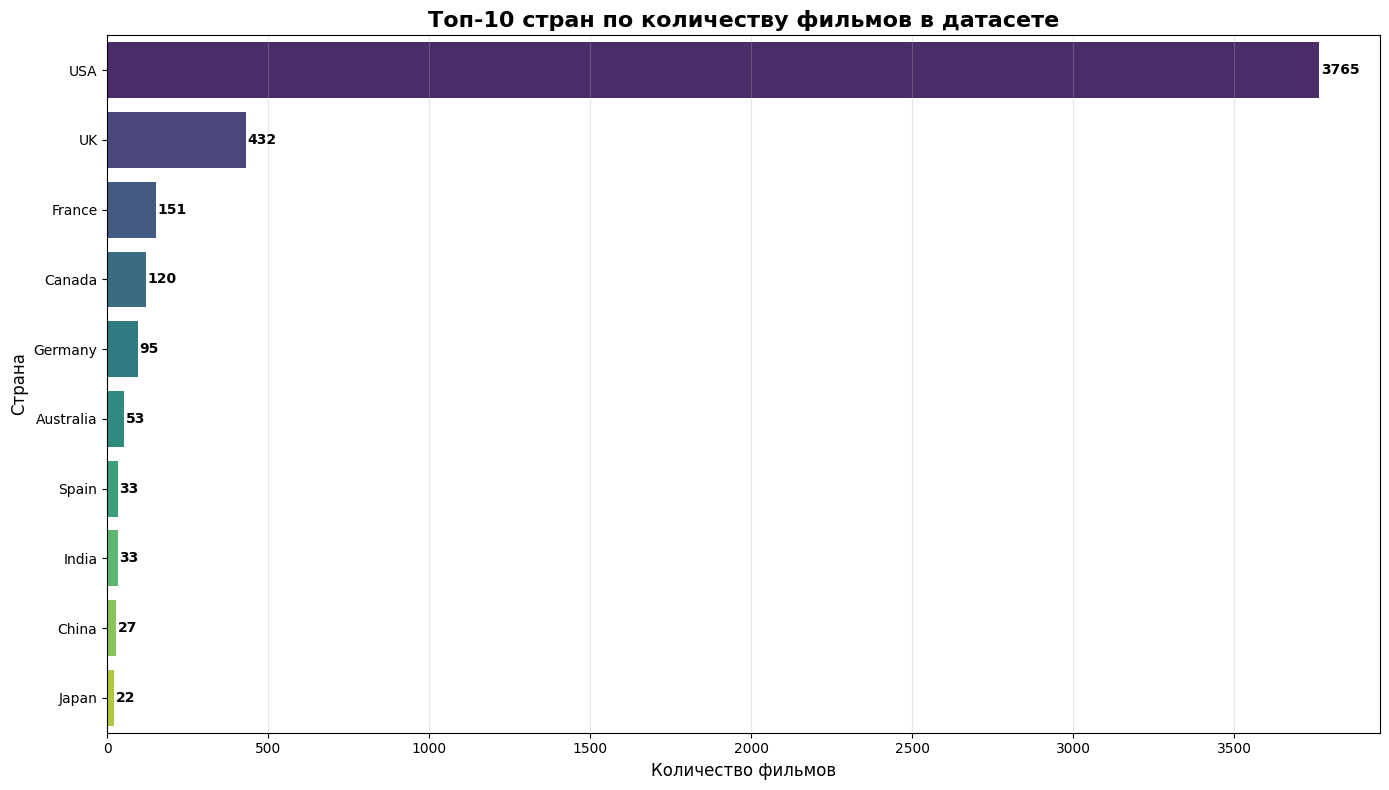

In [29]:
countries_films = movies_table_clean["country"].value_counts().head(10)

plt.figure(figsize=(14, 8))

sns.barplot(x=countries_films.values, 
            y=countries_films.index, 
            hue=countries_films.index,
            palette='viridis',
            legend=False,
            orient='h')

plt.title('Топ-10 стран по количеству фильмов в датасете', fontsize=16, fontweight='bold')
plt.xlabel('Количество фильмов', fontsize=12)
plt.ylabel('Страна', fontsize=12)

for i, (value, country) in enumerate(zip(countries_films.values, countries_films.index)):
    plt.text(value + 5, i, str(value), va='center', fontsize=10, fontweight='bold')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


США абсолютно лидирует.

### 8. Каково распределение длительности фильмов?

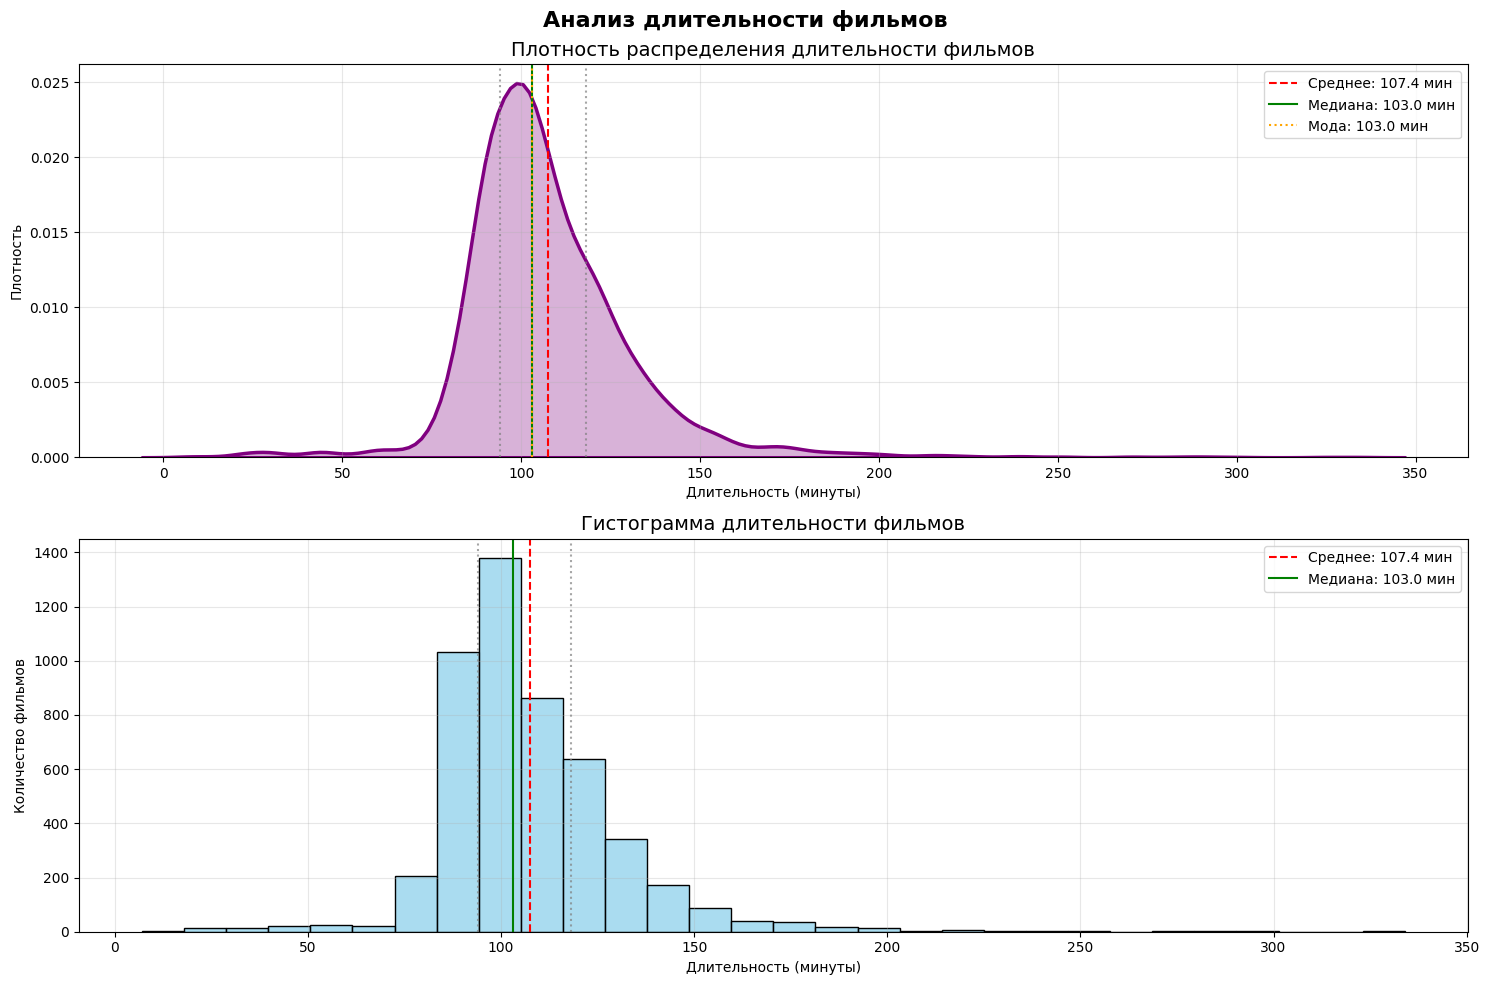

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
fig.suptitle('Анализ длительности фильмов', fontsize=16, fontweight='bold')

sns.kdeplot(movies_table_clean["duration"], ax=axes[0], color='purple', linewidth=2.5, fill=True, alpha=0.3)
axes[0].axvline(movies_table_clean["duration"].mean(), color='red', linestyle='--', 
                label=f'Среднее: {movies_table_clean["duration"].mean():.1f} мин')
axes[0].axvline(movies_table_clean["duration"].median(), color='green', linestyle='-', 
                label=f'Медиана: {movies_table_clean["duration"].median():.1f} мин')
axes[0].axvline(movies_table_clean["duration"].mode()[0], color='orange', linestyle=':', 
                label=f'Мода: {movies_table_clean["duration"].mode()[0]:.1f} мин')
axes[0].set_title('Плотность распределения длительности фильмов', fontsize=14)
axes[0].set_xlabel('Длительность (минуты)')
axes[0].set_ylabel('Плотность')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sns.histplot(movies_table_clean["duration"], ax=axes[1], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[1].axvline(movies_table_clean["duration"].mean(), color='red', linestyle='--', 
                label=f'Среднее: {movies_table_clean["duration"].mean():.1f} мин')
axes[1].axvline(movies_table_clean["duration"].median(), color='green', linestyle='-', 
                label=f'Медиана: {movies_table_clean["duration"].median():.1f} мин')
axes[1].set_title('Гистограмма длительности фильмов', fontsize=14)
axes[1].set_xlabel('Длительность (минуты)')
axes[1].set_ylabel('Количество фильмов')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for ax in axes:
    q25 = movies_table_clean["duration"].quantile(0.25)
    q75 = movies_table_clean["duration"].quantile(0.75)
    ax.axvline(q25, color='gray', linestyle=':', alpha=0.7, label=f'Q1 (25%): {q25:.1f} мин')
    ax.axvline(q75, color='gray', linestyle=':', alpha=0.7, label=f'Q3 (75%): {q75:.1f} мин')

plt.tight_layout()
plt.show()


Средняя длительность фильма составляет 107.4 минуты, медиана и мода — 103 минуты. Медиана ниже среднего, что указывает на наличие фильмов с большой длительностью, которые смещают среднее вправо. Большинство фильмов укладываются в стандартный хронометраж 90–120 минут.

### 9. Различаются ли кассовые сборы в зависимости от возрастного рейтинга?

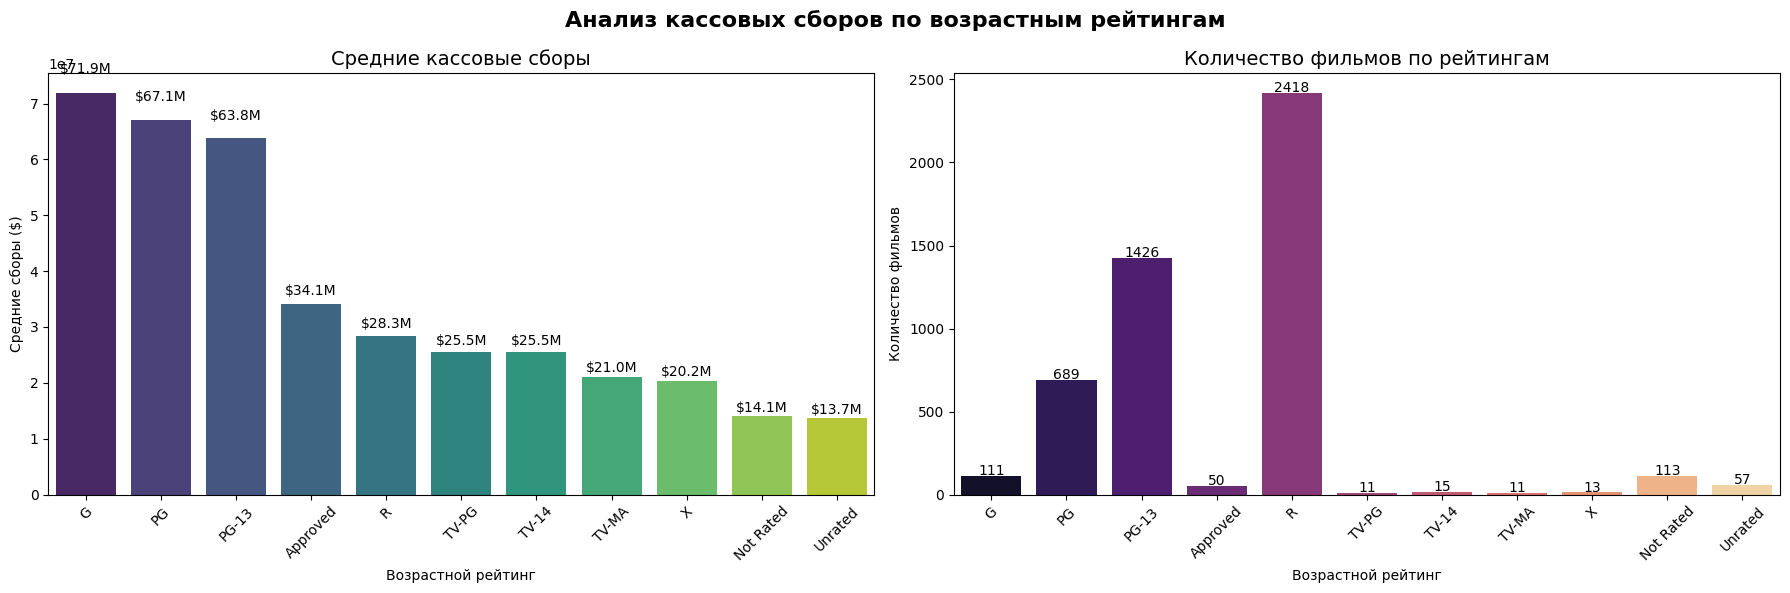

In [31]:
rating_stats = movies_table_clean.groupby('content_rating')['gross'].agg(['mean', 'median', 'count']).reset_index()
rating_stats = rating_stats[rating_stats['count'] >= 10].sort_values('mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Анализ кассовых сборов по возрастным рейтингам', fontsize=16, fontweight='bold')

ax1 = axes[0]
sns.barplot(data=rating_stats, x='content_rating', y='mean', 
            hue='content_rating', palette='viridis', legend=False, ax=ax1)
ax1.set_title('Средние кассовые сборы', fontsize=14)
ax1.set_xlabel('Возрастной рейтинг')
ax1.set_ylabel('Средние сборы ($)')
ax1.tick_params(axis='x', rotation=45)

for i, (_, row) in enumerate(rating_stats.iterrows()):
    ax1.text(i, row['mean'] + 0.05*row['mean'], f"${row['mean']/1e6:.1f}M", 
             ha='center', fontsize=10)

ax2 = axes[1]
sns.barplot(data=rating_stats, x='content_rating', y='count', 
            hue='content_rating', palette='magma', legend=False, ax=ax2)
ax2.set_title('Количество фильмов по рейтингам', fontsize=14)
ax2.set_xlabel('Возрастной рейтинг')
ax2.set_ylabel('Количество фильмов')
ax2.tick_params(axis='x', rotation=45)

for i, (_, row) in enumerate(rating_stats.iterrows()):
    ax2.text(i, row['count'] + 5, f"{row['count']}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Да, кассовые сборы заметно различаются в зависимости от возрастного рейтинга. Самые высокие средние сборы у фильмов с рейтингами G (7.1 млн) и PG (6.3 млн), что связано с ориентацией на семейную и детскую аудиторию. Фильмы с рейтингом PG-13 также собирают в среднем неплохо (3.4 млн), при этом они составляют самую многочисленную группу (63.8% всех фильмов). Рейтинги для взрослой аудитории (R, TV-MA, X) показывают более низкие средние сборы — от 0.9 до 2.5 млн.

### 10. Кто из режиссёров снял больше всего фильмов в данной выборке?

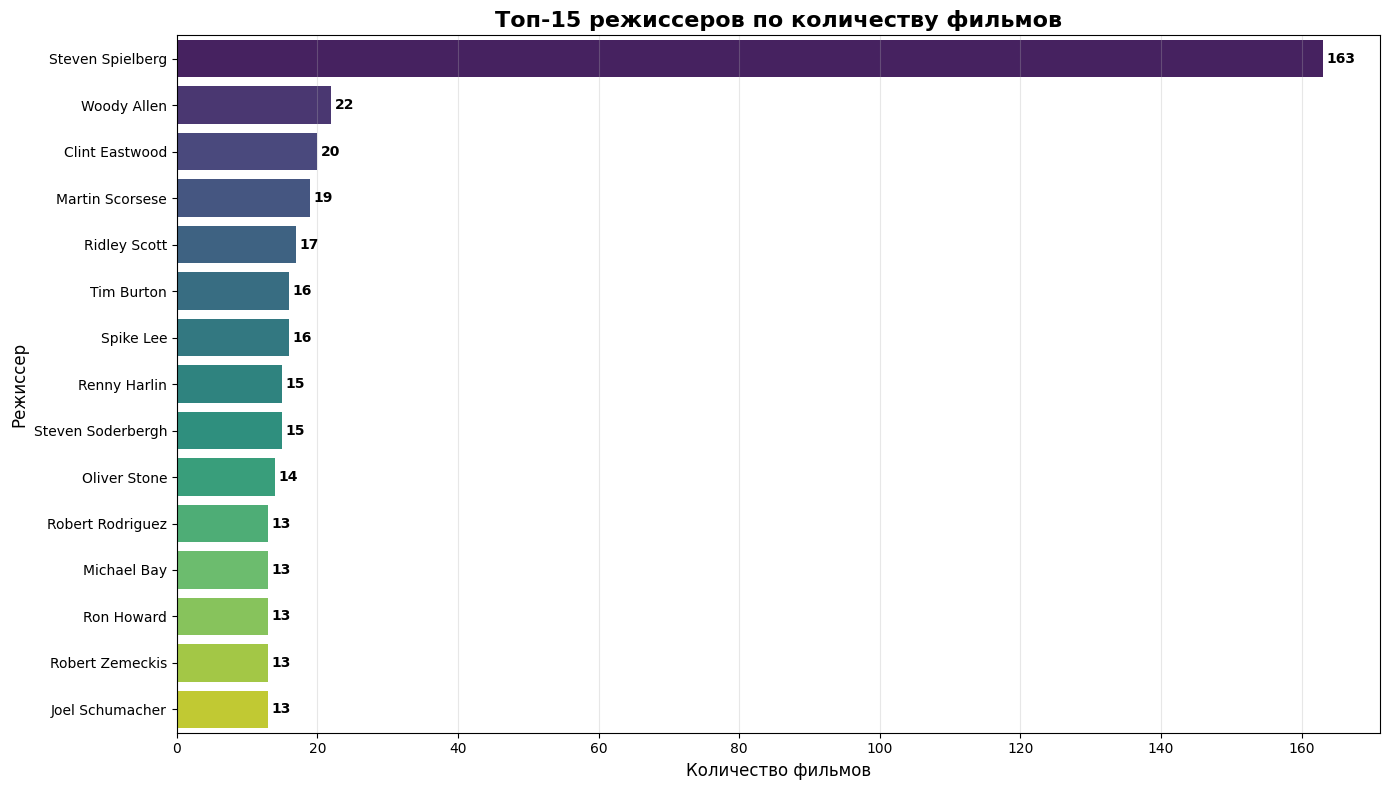

In [32]:
directors = movies_table_clean["Director_Name"].value_counts().head(15)

plt.figure(figsize=(14, 8))

sns.barplot(y=directors.index, x=directors.values, 
            hue=directors.index, palette='viridis', legend=False)

plt.title('Топ-15 режиссеров по количеству фильмов', fontsize=16, fontweight='bold')
plt.xlabel('Количество фильмов', fontsize=12)
plt.ylabel('Режиссер', fontsize=12)

for i, (value, name) in enumerate(zip(directors.values, directors.index)):
    plt.text(value + 0.5, i, str(value), va='center', fontsize=10, fontweight='bold')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Стивен Спилберг.

# Итоговый вывод

## Особенности получения данных
Прямой парсинг данных с сайта не удался из-за технических ограничений, поэтому данные были получены путем **копирования HTML-кода страницы** из инструментов разработчика браузера. HTML-содержимое было сохранено в файл `text.txt` с кодировкой latin-1, после чего выполнено его чтение и парсинг с помощью BeautifulSoup. В процессе обработки была извлечена таблица с индексами потребительских цен (CPI) за 1913–2016 годы, а также добавлен расчетный 1912 год.

В ходе анализа данных о фильмах были получены следующие основные результаты:

## 1. Качество данных и очистка
В исходных данных присутствовали явные ошибки (нулевые бюджеты, нереалистичные значения соотношения сторон), которые были удалены. Это позволило повысить достоверность дальнейшего анализа.

## 2. Рейтинги фильмов (IMDb)
- Большинство фильмов имеют рейтинг в диапазоне **6–7 баллов**
- Средний рейтинг составляет **6.4**, медиана — **6.6**
- Фильмов с очень высокими (9+) и очень низкими (<4) оценками мало

## 3. Бюджет и кассовые сборы
- Корреляция между бюджетом и сборами очень слабая (**r = 0.046**)
- Дорогие фильмы не гарантируют высоких сборов, а дешёвые могут стать хитами
- Средний бюджет рос до 2000-х годов (пик 6.5 млн $), после чего снизился

## 4. Влияние голосов на рейтинг
- Умеренная положительная корреляция (**r = 0.416**)
- Популярные фильмы имеют более высокие оценки, но среди них редко встречаются шедевры (9+)
- Наивысшие оценки чаще получают фильмы с умеренной популярностью (культовое кино)

## 5. Популярность актёров
- Связь между суммарными лайками актёров и рейтингом практически отсутствует
- Звёздный состав может привлечь внимание, но не определяет качество фильма

## 6. Длительность фильмов
- Средняя длительность — **107 минут**, медиана — **103 минуты**
- Большинство фильмов укладываются в стандартный хронометраж 90–120 минут

## 7. Возрастные рейтинги
- Самые высокие сборы у семейных рейтингов G и PG
- Рейтинг PG-13 доминирует по количеству фильмов (более 60%)

## 8. Жанры
- Наиболее распространённые жанры — драма, комедия, боевик
- Фильмы часто сочетают несколько жанров

---

**Общий вывод:** Успех фильма определяется множеством факторов, среди которых бюджет и популярность актёров не являются главными. Намного важнее сценарий, режиссура и попадание в ожидания целевой аудитории.